# Gait Analysis Global Data 탐색 및 분석

이 노트북은 `gait_analysis_global.csv` 파일을 분석합니다.

## 목차
1. 데이터 로드 및 기본 정보
2. 데이터 구조 파악
3. 그룹별 통계 분석
4. 속도 조건별 분석
5. 주요 보행 파라미터 시각화
6. 상관관계 분석

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 데이터 로드 및 기본 정보

In [2]:
# 데이터 파일 경로
data_path = Path("gait_analysis_global.csv")

# 데이터 로드
df = pd.read_csv(data_path)

print(f"📊 데이터 로드 완료")
print(f"   - 총 행 수: {len(df):,}")
print(f"   - 총 열 수: {len(df.columns)}")
print(f"\n데이터 미리보기:")
df.head()

📊 데이터 로드 완료
   - 총 행 수: 1,086
   - 총 열 수: 23

데이터 미리보기:


,group,participant,pace_condition,source_file,n_steps_total,n_strides_total,n_steps_trimmed,n_strides_trimmed,gait_speed_mps,cadence_spm,...,stride_time_sd_s,step_length_mean_m,step_length_sd_m,stride_length_mean_m,stride_length_sd_m,step_width_mean_m_orth,step_width_sd_m_orth,double_support_pct,single_support_L_pct,single_support_R_pct
0,ACLD,ACLD1,fast,FAST-001.mvnx,14,7,10,5,2.365,141.88,...,0.024,1.000,0.049,2.000,0.071,0.151,0.020,0.00,33.01,33.27
1,ACLD,ACLD1,fast,FAST-002.mvnx,15,7,11,5,2.450,145.05,...,0.024,0.971,0.147,2.033,0.030,0.149,0.028,0.00,32.58,33.26
2,ACLD,ACLD1,normal,nrml-001.mvnx,18,9,14,7,1.325,103.46,...,0.038,0.768,0.085,1.537,0.158,0.175,0.029,0.77,42.26,41.68
3,ACLD,ACLD1,normal,nrml-002.mvnx,18,9,14,7,1.295,103.72,...,0.040,0.749,0.040,1.498,0.068,0.164,0.036,0.00,41.63,41.24
4,ACLD,ACLD1,normal,nrml-003.mvnx,18,9,14,7,1.358,107.27,...,0.062,0.759,0.091,1.519,0.173,0.145,0.035,0.71,41.99,39.54


In [3]:
# 데이터 기본 정보
print("📋 데이터 정보:")
df.info()

📋 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1086 entries, 0 to 1085
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   group                   1086 non-null   object 
 1   participant             1086 non-null   object 
 2   pace_condition          1086 non-null   object 
 3   source_file             1086 non-null   object 
 4   n_steps_total           1086 non-null   int64  
 5   n_strides_total         1086 non-null   int64  
 6   n_steps_trimmed         1086 non-null   int64  
 7   n_strides_trimmed       1086 non-null   int64  
 8   gait_speed_mps          1086 non-null   float64
 9   cadence_spm             1086 non-null   float64
 10  step_time_mean_s        1086 non-null   float64
 11  step_time_sd_s          1086 non-null   float64
 12  stride_time_mean_s      1086 non-null   float64
 13  stride_time_sd_s        1086 non-null   float64
 14  step_length_mean_m      1086 n

In [4]:
# 결측치 확인
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    print("⚠️ 결측치 발견:")
    print(missing_data)
    print(f"\n결측치 비율:")
    print((missing_data / len(df) * 100).round(2))
else:
    print("✅ 결측치 없음")

⚠️ 결측치 발견:
step_width_mean_m_orth    14
dtype: int64

결측치 비율:
step_width_mean_m_orth    1.29
dtype: float64


## 2. 데이터 구조 파악

👥 그룹별 데이터 분포:
group
ACLD                   345
Healthy adolescents    304
Healthy adults         235
ACLR                   202
Name: count, dtype: int64


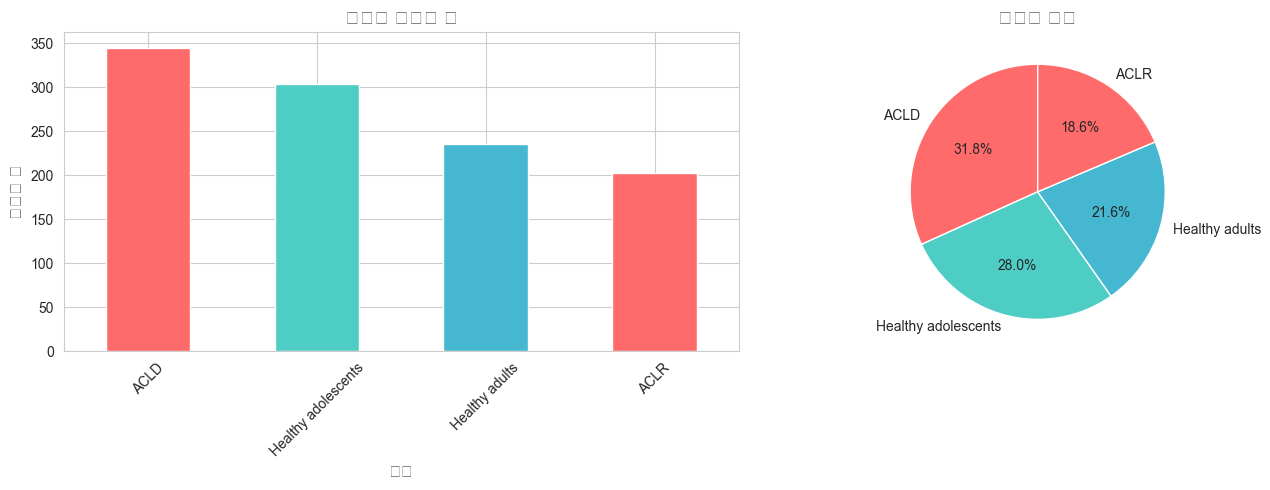

In [5]:
# 그룹별 데이터 분포
print("👥 그룹별 데이터 분포:")
group_counts = df['group'].value_counts()
print(group_counts)

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
group_counts.plot(kind='bar', ax=ax[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax[0].set_title('그룹별 데이터 수', fontsize=14, fontweight='bold')
ax[0].set_xlabel('그룹', fontsize=12)
ax[0].set_ylabel('데이터 수', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)

# 파이 차트
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax[1].pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%', 
          colors=colors, startangle=90)
ax[1].set_title('그룹별 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


🏃 속도 조건별 데이터 분포:
pace_condition
fast      389
normal    353
slow      344
Name: count, dtype: int64

📊 그룹 × 속도 조건 교차표:
pace_condition       fast  normal  slow
group                                  
ACLD                  115     118   112
ACLR                   67      68    67
Healthy adolescents   131      86    87
Healthy adults         76      81    78


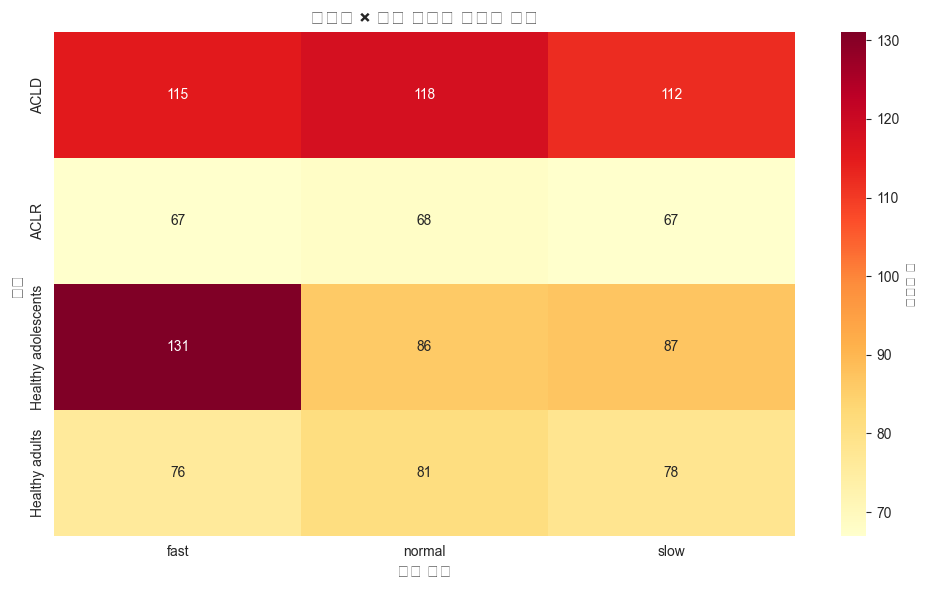

In [6]:
# 속도 조건별 데이터 분포
print("\n🏃 속도 조건별 데이터 분포:")
pace_counts = df['pace_condition'].value_counts()
print(pace_counts)

# 그룹 x 속도 조건 교차표
print("\n📊 그룹 × 속도 조건 교차표:")
crosstab = pd.crosstab(df['group'], df['pace_condition'])
print(crosstab)

# 히트맵으로 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': '데이터 수'})
plt.title('그룹별 × 속도 조건별 데이터 분포', fontsize=14, fontweight='bold')
plt.xlabel('속도 조건', fontsize=12)
plt.ylabel('그룹', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# 참가자 수 확인
print("\n👤 그룹별 참가자 수:")
participants_per_group = df.groupby('group')['participant'].nunique()
print(participants_per_group)


👤 그룹별 참가자 수:
group
ACLD                   40
ACLR                   27
Healthy adolescents    22
Healthy adults         25
Name: participant, dtype: int64


## 3. 그룹별 통계 분석

In [8]:
# 주요 보행 파라미터 선택
key_params = [
    'gait_speed_mps',
    'cadence_spm',
    'step_time_mean_s',
    'stride_time_mean_s',
    'step_length_mean_m',
    'stride_length_mean_m',
    'step_width_mean_m_orth'
]

# 그룹별 기술 통계
print("📈 그룹별 주요 보행 파라미터 평균:")
group_stats = df.groupby('group')[key_params].mean()
print(group_stats.round(3))

📈 그룹별 주요 보행 파라미터 평균:
                     gait_speed_mps  cadence_spm  step_time_mean_s  \
group                                                                
ACLD                          1.241      104.431             0.593   
ACLR                          1.223      102.418             0.601   
Healthy adolescents           1.449      113.047             0.544   
Healthy adults                1.374      111.906             0.558   

                     stride_time_mean_s  step_length_mean_m  \
group                                                         
ACLD                              1.185               0.692   
ACLR                              1.203               0.698   
Healthy adolescents               1.088               0.755   
Healthy adults                    1.116               0.713   

                     stride_length_mean_m  step_width_mean_m_orth  
group                                                              
ACLD                                1.388  

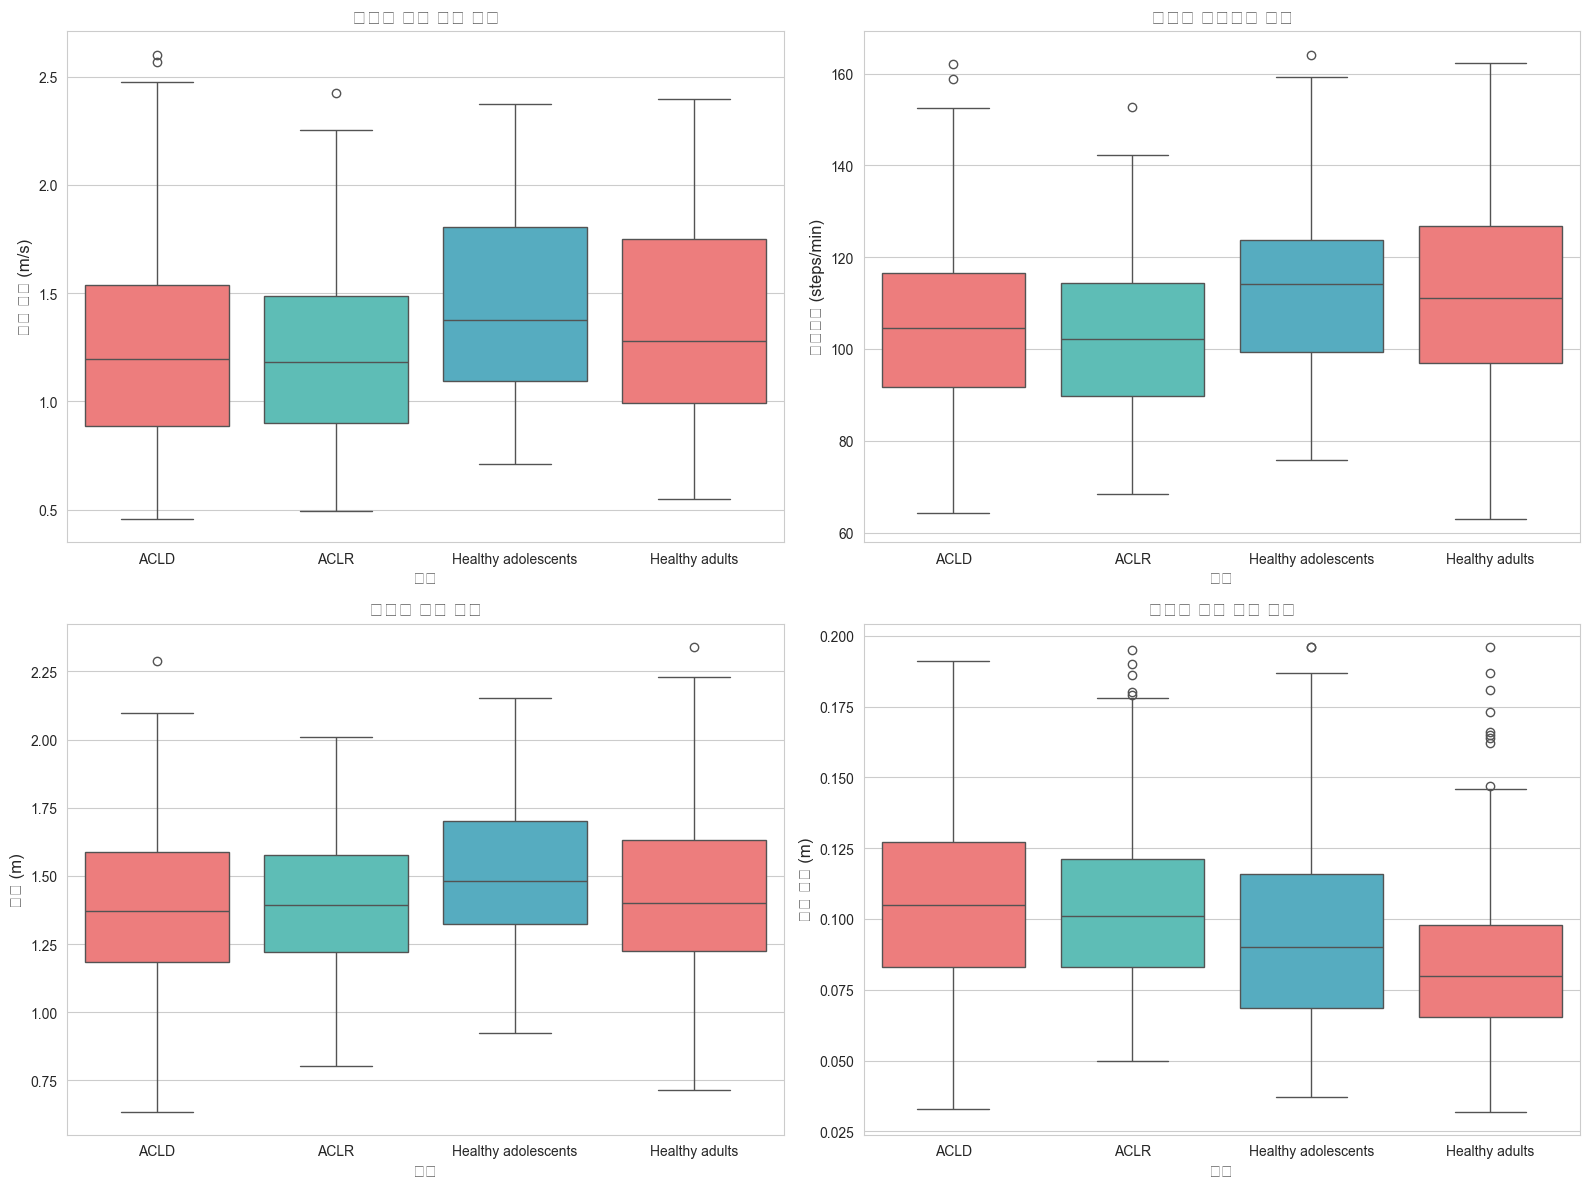

In [9]:
# 보행 속도 비교 (그룹별)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 보행 속도 박스플롯
sns.boxplot(data=df, x='group', y='gait_speed_mps', ax=axes[0, 0], 
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('그룹별 보행 속도 분포', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('그룹', fontsize=12)
axes[0, 0].set_ylabel('보행 속도 (m/s)', fontsize=12)

# 2. 케이던스 박스플롯
sns.boxplot(data=df, x='group', y='cadence_spm', ax=axes[0, 1],
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_title('그룹별 케이던스 분포', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('그룹', fontsize=12)
axes[0, 1].set_ylabel('케이던스 (steps/min)', fontsize=12)

# 3. 보폭 박스플롯
sns.boxplot(data=df, x='group', y='stride_length_mean_m', ax=axes[1, 0],
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 0].set_title('그룹별 보폭 분포', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('그룹', fontsize=12)
axes[1, 0].set_ylabel('보폭 (m)', fontsize=12)

# 4. 보폭 너비 박스플롯
sns.boxplot(data=df, x='group', y='step_width_mean_m_orth', ax=axes[1, 1],
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 1].set_title('그룹별 보폭 너비 분포', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('그룹', fontsize=12)
axes[1, 1].set_ylabel('보폭 너비 (m)', fontsize=12)

plt.tight_layout()
plt.show()

## 4. 속도 조건별 분석

In [10]:
# 속도 조건별 보행 파라미터 비교
print("🏃 속도 조건별 주요 보행 파라미터 평균:")
pace_stats = df.groupby('pace_condition')[key_params].mean()
print(pace_stats.round(3))

🏃 속도 조건별 주요 보행 파라미터 평균:
                gait_speed_mps  cadence_spm  step_time_mean_s  \
pace_condition                                                  
fast                     1.796      126.714             0.478   
normal                   1.243      106.588             0.567   
slow                     0.876       88.559             0.688   

                stride_time_mean_s  step_length_mean_m  stride_length_mean_m  \
pace_condition                                                                 
fast                         0.955               0.845                 1.699   
normal                       1.134               0.696                 1.397   
slow                         1.375               0.589                 1.181   

                step_width_mean_m_orth  
pace_condition                          
fast                             0.103  
normal                           0.098  
slow                             0.094  


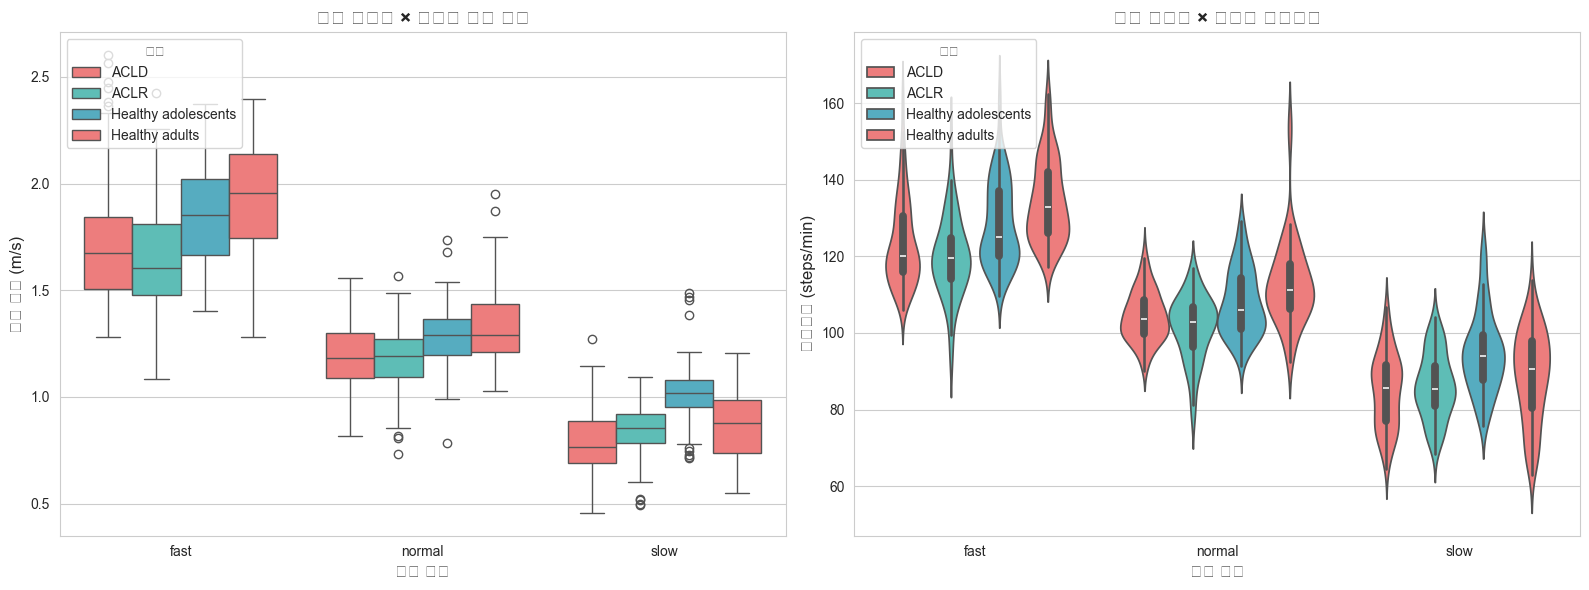

In [11]:
# 그룹 × 속도 조건별 보행 속도 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 박스플롯
sns.boxplot(data=df, x='pace_condition', y='gait_speed_mps', hue='group', ax=axes[0],
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('속도 조건별 × 그룹별 보행 속도', fontsize=14, fontweight='bold')
axes[0].set_xlabel('속도 조건', fontsize=12)
axes[0].set_ylabel('보행 속도 (m/s)', fontsize=12)
axes[0].legend(title='그룹', loc='upper left')

# 2. 바이올린 플롯
sns.violinplot(data=df, x='pace_condition', y='cadence_spm', hue='group', ax=axes[1],
               palette=['#FF6B6B', '#4ECDC4', '#45B7D1'], split=False)
axes[1].set_title('속도 조건별 × 그룹별 케이던스', fontsize=14, fontweight='bold')
axes[1].set_xlabel('속도 조건', fontsize=12)
axes[1].set_ylabel('케이던스 (steps/min)', fontsize=12)
axes[1].legend(title='그룹', loc='upper left')

plt.tight_layout()
plt.show()

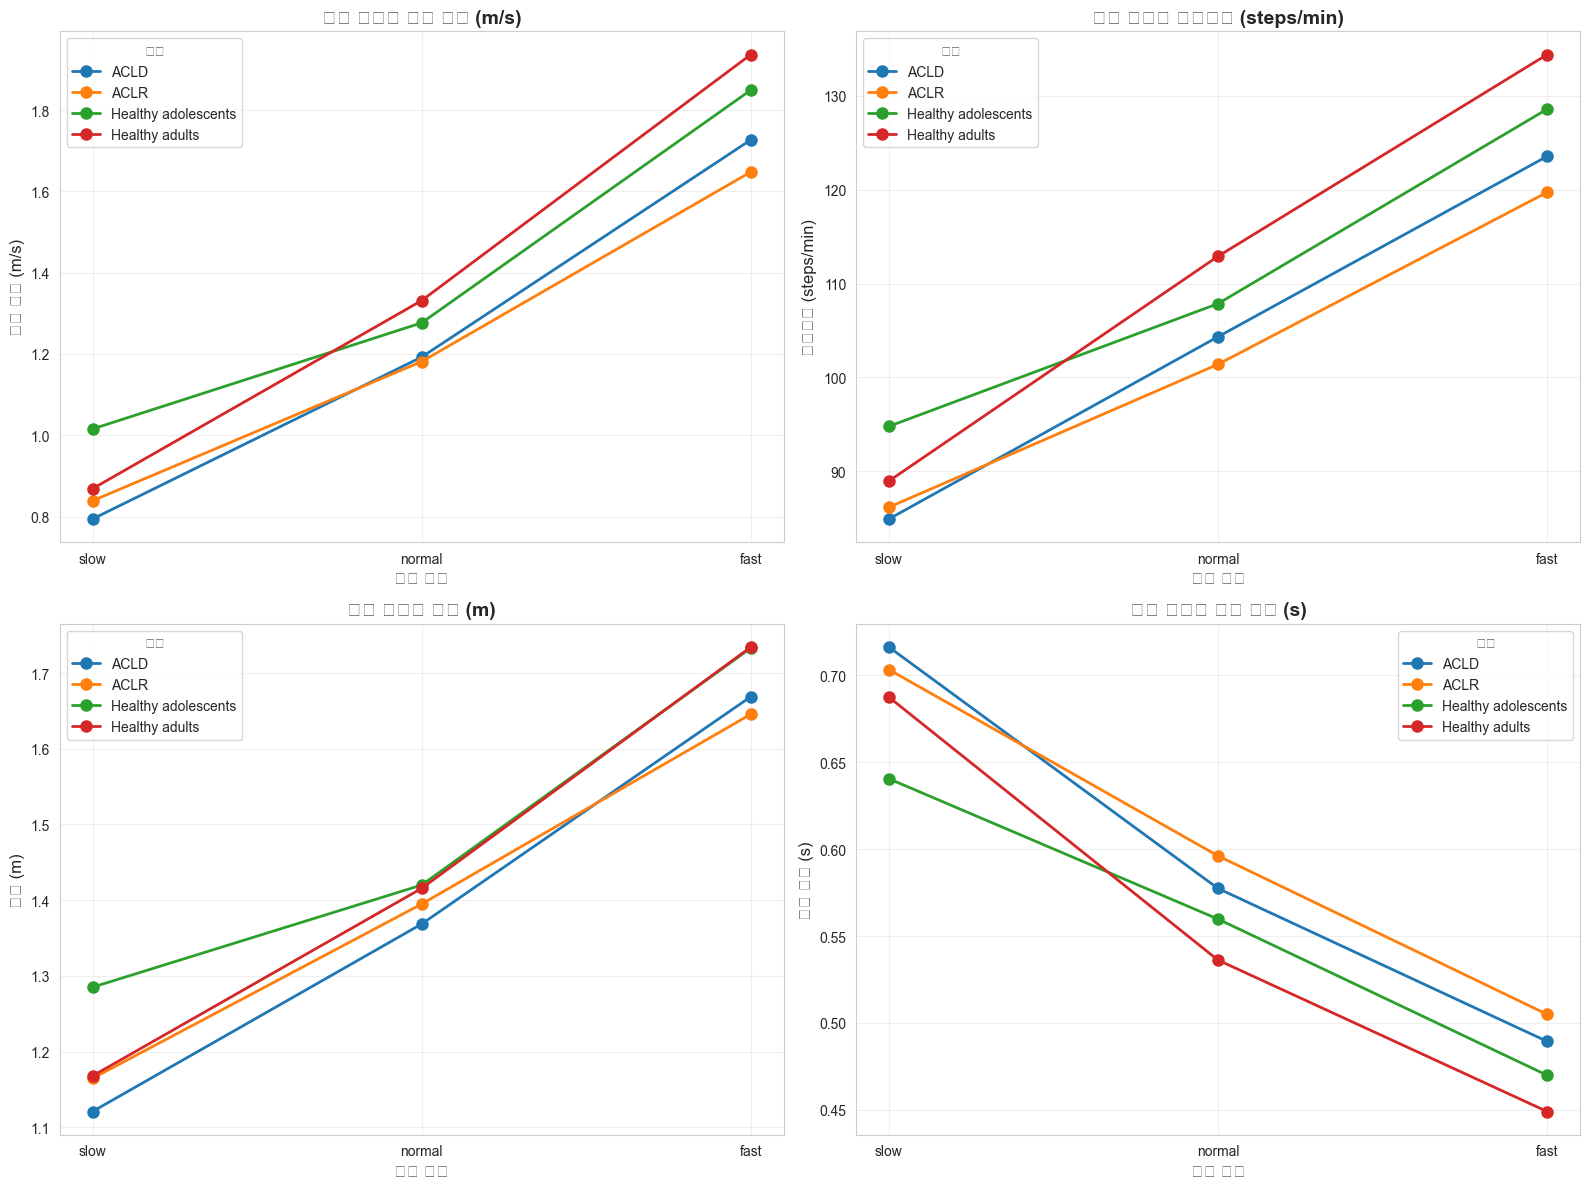

In [12]:
# 속도 조건에 따른 보행 파라미터 변화
pace_order = ['slow', 'normal', 'fast']
df['pace_condition'] = pd.Categorical(df['pace_condition'], categories=pace_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (param, title) in enumerate([
    ('gait_speed_mps', '보행 속도 (m/s)'),
    ('cadence_spm', '케이던스 (steps/min)'),
    ('stride_length_mean_m', '보폭 (m)'),
    ('step_time_mean_s', '스텝 시간 (s)')
]):
    row = idx // 2
    col = idx % 2
    
    for group in df['group'].unique():
        group_data = df[df['group'] == group].groupby('pace_condition')[param].mean()
        axes[row, col].plot(group_data.index, group_data.values, marker='o', 
                           label=group, linewidth=2, markersize=8)
    
    axes[row, col].set_title(f'속도 조건별 {title}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('속도 조건', fontsize=12)
    axes[row, col].set_ylabel(title, fontsize=12)
    axes[row, col].legend(title='그룹')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 주요 보행 파라미터 시각화

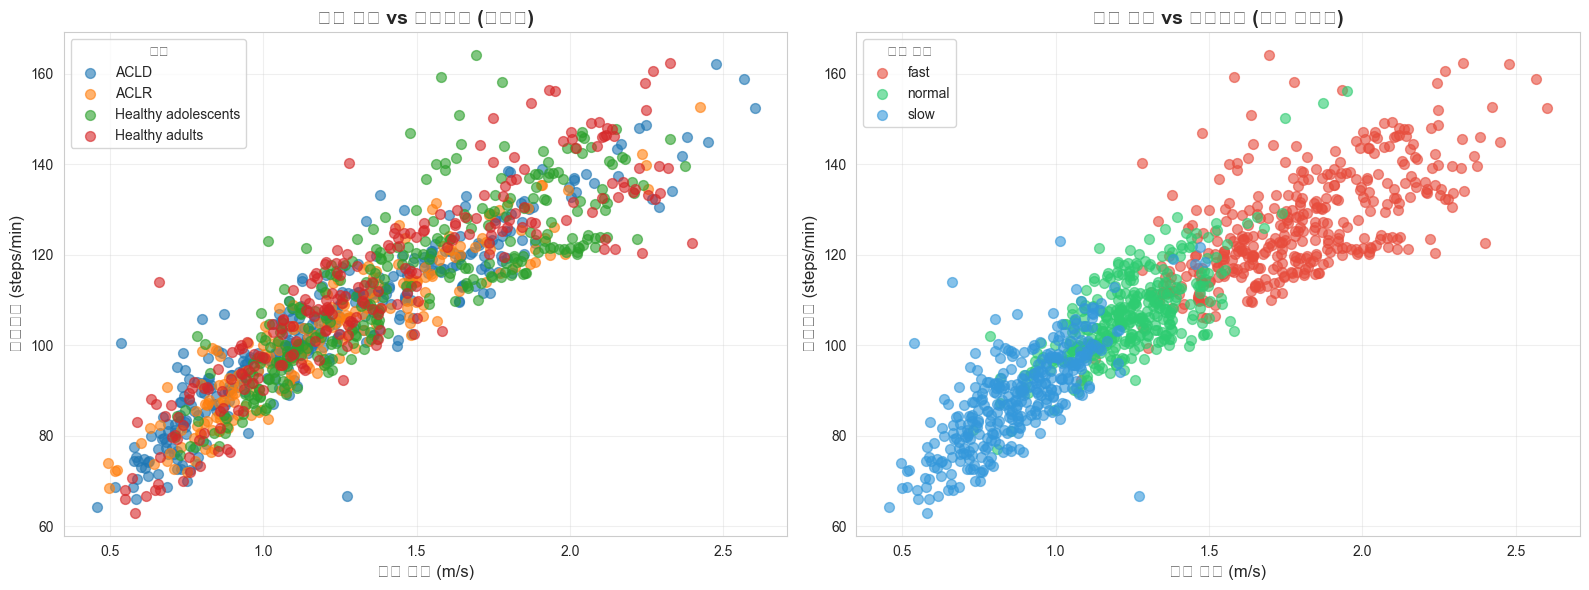

In [13]:
# 보행 속도와 케이던스 관계
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 산점도 (그룹별)
for group in df['group'].unique():
    group_data = df[df['group'] == group]
    axes[0].scatter(group_data['gait_speed_mps'], group_data['cadence_spm'], 
                   label=group, alpha=0.6, s=50)

axes[0].set_title('보행 속도 vs 케이던스 (그룹별)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('보행 속도 (m/s)', fontsize=12)
axes[0].set_ylabel('케이던스 (steps/min)', fontsize=12)
axes[0].legend(title='그룹')
axes[0].grid(True, alpha=0.3)

# 2. 산점도 (속도 조건별)
pace_colors = {'slow': '#3498db', 'normal': '#2ecc71', 'fast': '#e74c3c'}
for pace in df['pace_condition'].unique():
    pace_data = df[df['pace_condition'] == pace]
    axes[1].scatter(pace_data['gait_speed_mps'], pace_data['cadence_spm'], 
                   label=pace, alpha=0.6, s=50, c=pace_colors.get(pace, '#95a5a6'))

axes[1].set_title('보행 속도 vs 케이던스 (속도 조건별)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('보행 속도 (m/s)', fontsize=12)
axes[1].set_ylabel('케이던스 (steps/min)', fontsize=12)
axes[1].legend(title='속도 조건')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

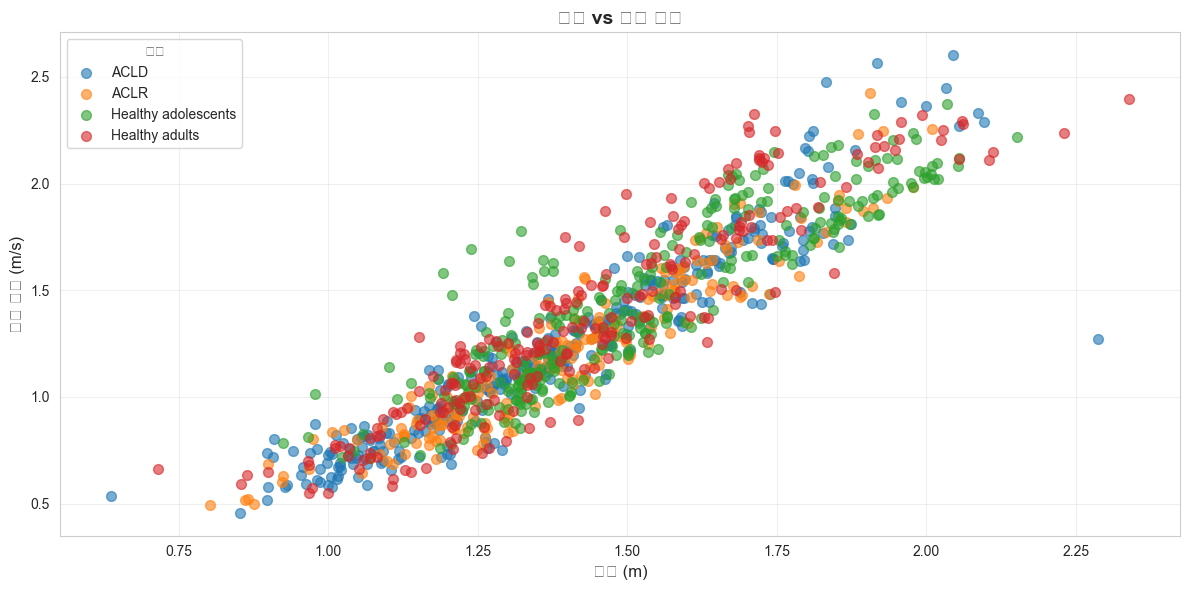

In [14]:
# 보폭과 보행 속도 관계
plt.figure(figsize=(12, 6))

for group in df['group'].unique():
    group_data = df[df['group'] == group]
    plt.scatter(group_data['stride_length_mean_m'], group_data['gait_speed_mps'], 
               label=group, alpha=0.6, s=50)

plt.title('보폭 vs 보행 속도', fontsize=14, fontweight='bold')
plt.xlabel('보폭 (m)', fontsize=12)
plt.ylabel('보행 속도 (m/s)', fontsize=12)
plt.legend(title='그룹')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

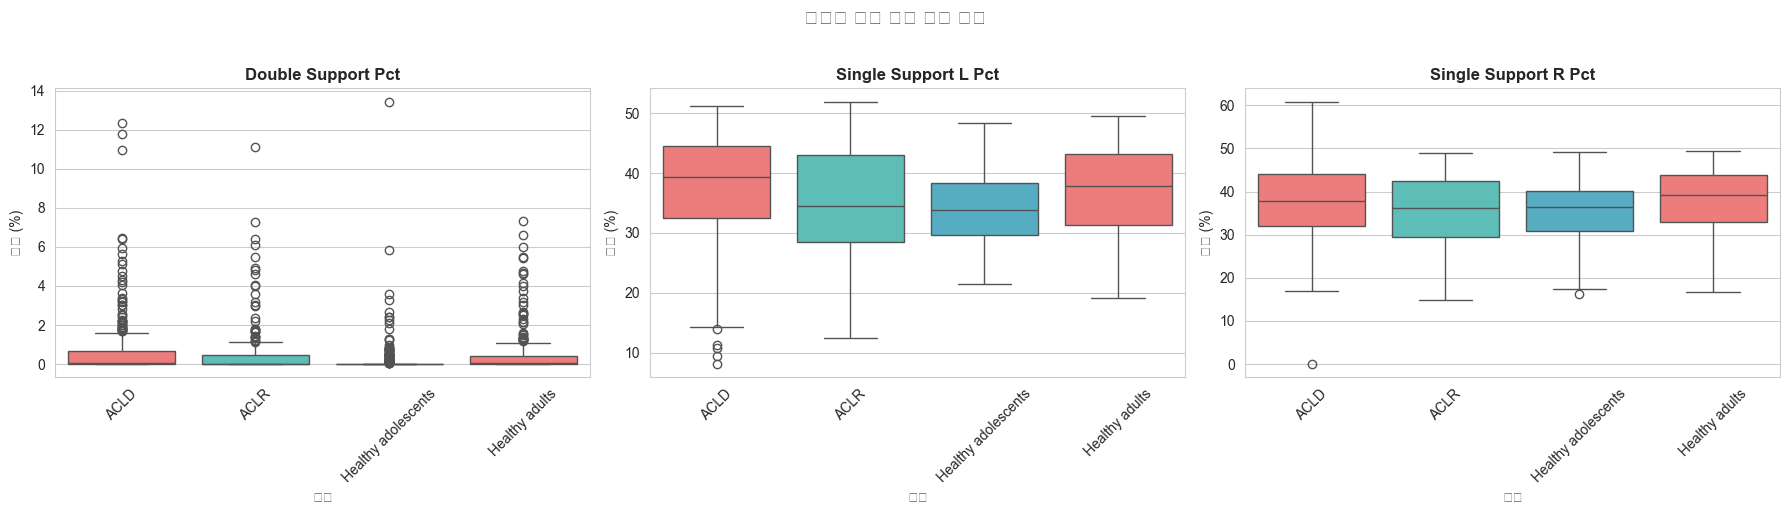

In [15]:
# 지지 시간 비율 분석
support_params = ['double_support_pct', 'single_support_L_pct', 'single_support_R_pct']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, param in enumerate(support_params):
    sns.boxplot(data=df, x='group', y=param, ax=axes[idx],
                palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[idx].set_title(param.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('그룹', fontsize=10)
    axes[idx].set_ylabel('비율 (%)', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('그룹별 지지 시간 비율 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. 상관관계 분석

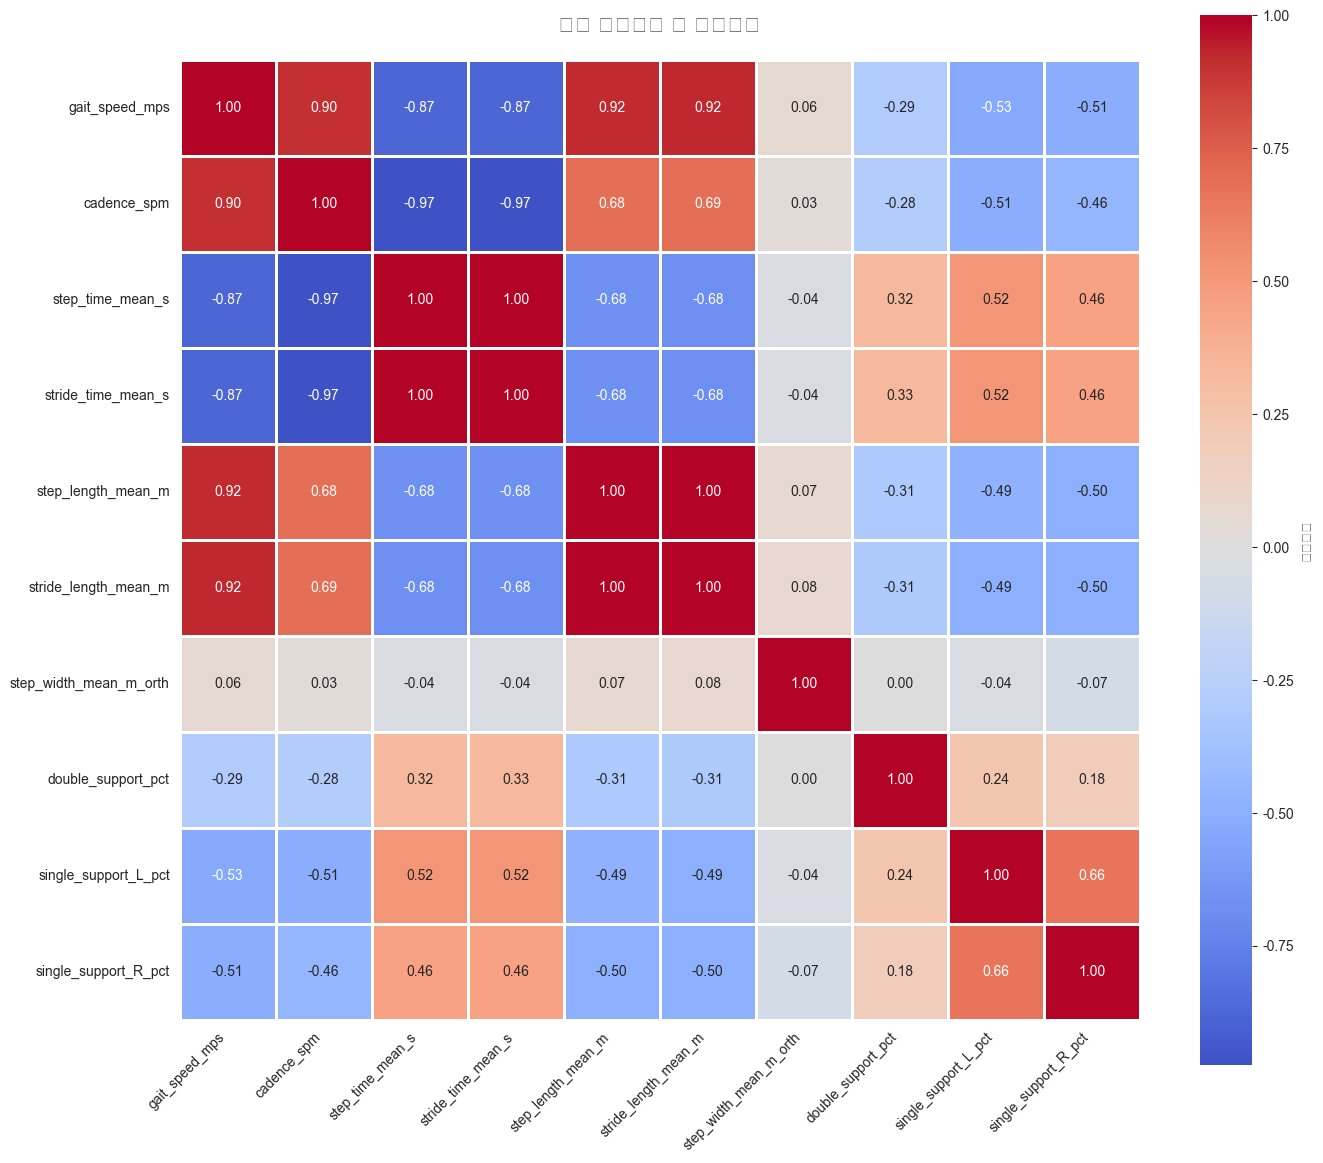

In [16]:
# 주요 파라미터 간 상관관계 계산
correlation_params = [
    'gait_speed_mps', 'cadence_spm', 'step_time_mean_s', 'stride_time_mean_s',
    'step_length_mean_m', 'stride_length_mean_m', 'step_width_mean_m_orth',
    'double_support_pct', 'single_support_L_pct', 'single_support_R_pct'
]

corr_matrix = df[correlation_params].corr()

# 상관관계 히트맵
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': '상관계수'})
plt.title('보행 파라미터 간 상관관계', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# 강한 상관관계 확인 (|r| > 0.7)
print("\n🔍 강한 상관관계 (|r| > 0.7):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                '변수1': corr_matrix.columns[i],
                '변수2': corr_matrix.columns[j],
                '상관계수': corr_matrix.iloc[i, j]
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('상관계수', key=abs, ascending=False)
print(strong_corr_df.to_string(index=False))


🔍 강한 상관관계 (|r| > 0.7):
               변수1                  변수2      상관계수
  step_time_mean_s   stride_time_mean_s  0.999493
step_length_mean_m stride_length_mean_m  0.998026
       cadence_spm     step_time_mean_s -0.973774
       cadence_spm   stride_time_mean_s -0.973000
    gait_speed_mps stride_length_mean_m  0.922994
    gait_speed_mps   step_length_mean_m  0.920529
    gait_speed_mps          cadence_spm  0.904440
    gait_speed_mps   stride_time_mean_s -0.874509
    gait_speed_mps     step_time_mean_s -0.874464


## 7. 요약 통계

In [18]:
# 전체 데이터 요약 통계
print("📊 전체 데이터 요약 통계:")
summary_stats = df[key_params].describe()
print(summary_stats.round(3))

📊 전체 데이터 요약 통계:
       gait_speed_mps  cadence_spm  step_time_mean_s  stride_time_mean_s  \
count        1086.000     1086.000          1086.000            1086.000   
mean            1.324      108.086             0.573               1.146   
std             0.437       19.120             0.106               0.213   
min             0.457       62.960             0.366               0.731   
25%             0.990       94.648             0.497               0.993   
50%             1.258      107.555             0.558               1.116   
75%             1.641      120.795             0.634               1.267   
max             2.602      164.130             0.953               1.906   

       step_length_mean_m  stride_length_mean_m  step_width_mean_m_orth  
count            1086.000              1086.000                1072.000  
mean                0.716                 1.437                   0.098  
std                 0.134                 0.270                   0.033  
min

In [19]:
# 그룹별 × 속도 조건별 평균 보행 속도 테이블
print("\n📈 그룹별 × 속도 조건별 평균 보행 속도 (m/s):")
pivot_speed = df.pivot_table(values='gait_speed_mps', 
                              index='group', 
                              columns='pace_condition', 
                              aggfunc='mean')
print(pivot_speed.round(3))


📈 그룹별 × 속도 조건별 평균 보행 속도 (m/s):
pace_condition        slow  normal   fast
group                                    
ACLD                 0.794   1.192  1.727
ACLR                 0.839   1.181  1.648
Healthy adolescents  1.015   1.277  1.850
Healthy adults       0.868   1.331  1.937


In [20]:
# 그룹별 × 속도 조건별 평균 케이던스 테이블
print("\n📈 그룹별 × 속도 조건별 평균 케이던스 (steps/min):")
pivot_cadence = df.pivot_table(values='cadence_spm', 
                                index='group', 
                                columns='pace_condition', 
                                aggfunc='mean')
print(pivot_cadence.round(2))


📈 그룹별 × 속도 조건별 평균 케이던스 (steps/min):
pace_condition        slow  normal    fast
group                                     
ACLD                 84.90  104.33  123.56
ACLR                 86.16  101.39  119.72
Healthy adolescents  94.77  107.86  128.59
Healthy adults       88.94  112.90  134.41


In [21]:
print("\n✅ 분석 완료!")
print(f"\n📌 주요 발견사항:")
print(f"   1. 총 {len(df):,}개의 보행 데이터 분석")
print(f"   2. {df['group'].nunique()}개 그룹: {', '.join(df['group'].unique())}")
print(f"   3. {df['pace_condition'].nunique()}개 속도 조건: {', '.join(df['pace_condition'].unique())}")
print(f"   4. 총 {df['participant'].nunique()}명의 참가자 데이터")


✅ 분석 완료!

📌 주요 발견사항:
   1. 총 1,086개의 보행 데이터 분석
   2. 4개 그룹: ACLD, ACLR, Healthy adolescents, Healthy adults
   3. 3개 속도 조건: fast, normal, slow
   4. 총 114명의 참가자 데이터
